# Sensorless Drive Diagnosis — Fault Classification

**Dataset:** UCI "Dataset for Sensorless Drive Diagnosis" (ID 325)
**Task:** Multi-class classification (11 classes) — diagnose motor drive condition (1 healthy + 10 fault states) from 48 statistical features extracted from electric current signals.
**Models:** Logistic Regression, Decision Tree, K-Nearest Neighbors, Naive Bayes (Gaussian), Random Forest (Ensemble)
**Metrics:** Accuracy, AUC (macro, one-vs-rest), Precision (macro), Recall (macro), F1 (macro), MCC


In [15]:
import os

In [16]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, matthews_corrcoef,
                              confusion_matrix, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")


## 1. Load Dataset

Primary method: UCI's own `ucimlrepo` package (recommended by UCI, resolves the dataset regardless of file-format changes on their end).
Fallback: a local copy at `../data/Sensorless_drive_diagnosis.txt` (whitespace-separated, no header, 48 feature columns + 1 target column) — use this if the lab machine has no internet access or `ucimlrepo` is unavailable.

In [17]:
from ucimlrepo import fetch_ucirepo
COLUMNS = [f"feature_{i+1}" for i in range(48)] + ["target"]

df = pd.read_csv(
    "data/Sensorless_drive_diagnosis.txt",
    sep=r"\s+",
    header=None,
    names=COLUMNS
)
df = pd.read_csv(
    "data/Sensorless_drive_diagnosis.txt",
    sep=r"\s+",
    header=None,
    names=COLUMNS
)

In [18]:
N_FEATURES = 48
df.head()


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,target
0,-3.014600e-07,8.260300e-06,-0.000012,-0.000002,-1.438600e-06,-0.000021,0.031718,0.031710,0.031721,-0.032963,...,-0.63308,2.9646,8.1198,-1.4961,-1.4961,-1.4961,-1.4996,-1.4996,-1.4996,1
1,2.913200e-06,-5.247700e-06,0.000003,-0.000006,2.778900e-06,-0.000004,0.030804,0.030810,0.030806,-0.033520,...,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
2,-2.951700e-06,-3.184000e-06,-0.000016,-0.000001,-1.575300e-06,0.000017,0.032877,0.032880,0.032896,-0.029834,...,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
3,-1.322600e-06,8.820100e-06,-0.000016,-0.000005,-7.282900e-07,0.000004,0.029410,0.029401,0.029417,-0.030156,...,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
4,-6.836600e-08,5.666300e-07,-0.000026,-0.000006,-7.940600e-07,0.000013,0.030119,0.030119,0.030145,-0.031393,...,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1


## 2. Exploratory Data Analysis

In [19]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 58509 entries, 0 to 58508
Data columns (total 49 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   58509 non-null  float64
 1   feature_2   58509 non-null  float64
 2   feature_3   58509 non-null  float64
 3   feature_4   58509 non-null  float64
 4   feature_5   58509 non-null  float64
 5   feature_6   58509 non-null  float64
 6   feature_7   58509 non-null  float64
 7   feature_8   58509 non-null  float64
 8   feature_9   58509 non-null  float64
 9   feature_10  58509 non-null  float64
 10  feature_11  58509 non-null  float64
 11  feature_12  58509 non-null  float64
 12  feature_13  58509 non-null  float64
 13  feature_14  58509 non-null  float64
 14  feature_15  58509 non-null  float64
 15  feature_16  58509 non-null  float64
 16  feature_17  58509 non-null  float64
 17  feature_18  58509 non-null  float64
 18  feature_19  58509 non-null  float64
 19  feature_20  58509 non-null  float64


In [20]:
df.describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
feature_1,58509.0,-3.332852e-06,0.000072,-0.013721,-0.000007,-2.652600e-06,0.000002,0.005784
feature_2,58509.0,1.439648e-06,0.000056,-0.005414,-0.000014,8.804600e-07,0.000019,0.004525
feature_3,58509.0,1.412013e-06,0.000235,-0.013580,-0.000072,5.137700e-07,0.000075,0.005238
feature_4,58509.0,-1.312815e-06,0.000063,-0.012787,-0.000005,-1.059100e-06,0.000004,0.001453
feature_5,58509.0,1.351239e-06,0.000057,-0.008356,-0.000015,7.540200e-07,0.000019,0.000825
feature_6,58509.0,-2.654483e-07,0.000226,-0.009741,-0.000074,-1.659300e-07,0.000071,0.002754
feature_7,58509.0,1.914585e-03,0.036468,-0.139890,-0.019927,1.322600e-02,0.024770,0.069125
feature_8,58509.0,1.913146e-03,0.036465,-0.135940,-0.019951,1.323000e-02,0.024776,0.069130
feature_9,58509.0,1.911733e-03,0.036470,-0.130860,-0.019925,1.324700e-02,0.024777,0.069131
feature_10,58509.0,-1.189731e-02,0.066482,-0.218640,-0.032144,-1.556600e-02,0.020614,0.352580


target
1     5319
2     5319
3     5319
4     5319
5     5319
6     5319
7     5319
8     5319
9     5319
10    5319
11    5319
Name: count, dtype: int64


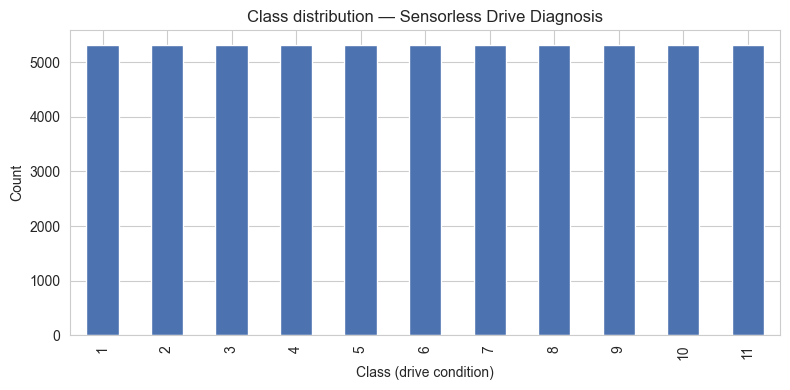

In [21]:
class_counts = df["target"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar", color="#4C72B0")
plt.title("Class distribution — Sensorless Drive Diagnosis")
plt.xlabel("Class (drive condition)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The dataset is perfectly balanced across all 11 classes (5,319 rows each), so accuracy is a fair metric here and macro-averaging for precision/recall/F1/AUC won't be skewed by class imbalance.


## 3. Train/Test Split & Preprocessing

In [22]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: (43881, 48)  Test: (14628, 48)


## 4. Train Models & Evaluate

All 5 models


In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

results = {}
fitted_models = {}
predictions = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_pred),
    }
    fitted_models[name] = model
    predictions[name] = y_pred
    print(f"{name:28s} trained in {time.time()-t0:5.1f}s  "
          f"acc={results[name]['Accuracy']:.4f}  f1={results[name]['F1']:.4f}  mcc={results[name]['MCC']:.4f}")


Logistic Regression          trained in   8.6s  acc=0.9178  f1=0.9176  mcc=0.9096
Decision Tree                trained in   5.3s  acc=0.9840  f1=0.9840  mcc=0.9824
kNN                          trained in   6.5s  acc=0.8255  f1=0.8258  mcc=0.8082
Naive Bayes                  trained in   0.4s  acc=0.7453  f1=0.7066  mcc=0.7286
Random Forest (Ensemble)     trained in  33.6s  acc=0.9989  f1=0.9989  mcc=0.9988


## 5. Comparison Table

In [24]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df[["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]]
results_df


,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.9178,0.9952,0.9176,0.9178,0.9176,0.9096
Decision Tree,0.9840,0.9912,0.9840,0.9840,0.9840,0.9824
kNN,0.8255,0.9727,0.8285,0.8255,0.8258,0.8082
Naive Bayes,0.7453,0.9843,0.7887,0.7453,0.7066,0.7286
Random Forest (Ensemble),0.9989,1.0000,0.9989,0.9989,0.9989,0.9988


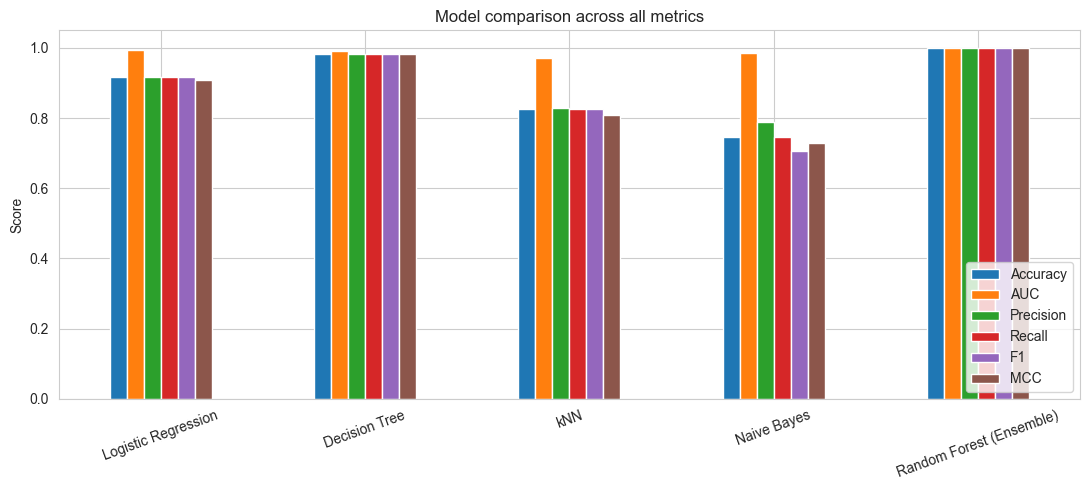

In [25]:
results_df.plot(kind="bar", figsize=(11, 5))
plt.title("Model comparison across all metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 6. Confusion Matrix — best-performing model

Best model by F1: Random Forest (Ensemble)


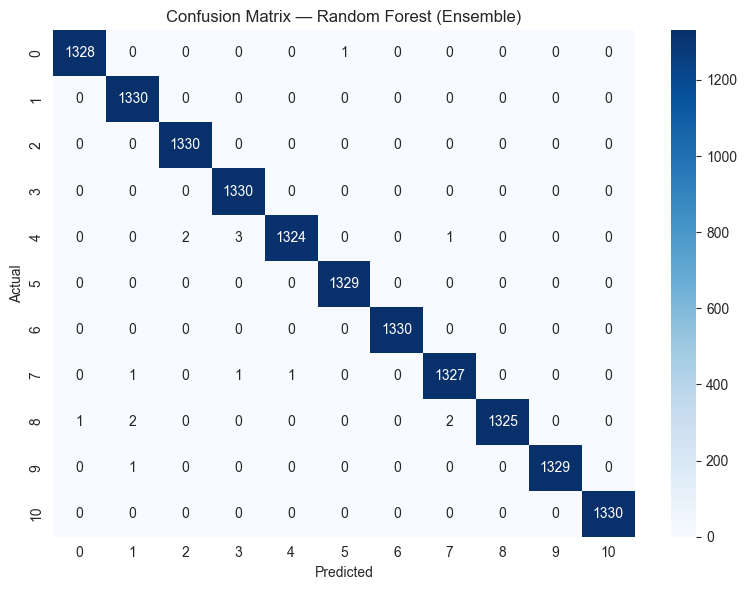

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1329
           2       1.00      1.00      1.00      1330
           3       1.00      1.00      1.00      1330
           4       1.00      1.00      1.00      1330
           5       1.00      1.00      1.00      1330
           6       1.00      1.00      1.00      1329
           7       1.00      1.00      1.00      1330
           8       1.00      1.00      1.00      1330
           9       1.00      1.00      1.00      1330
          10       1.00      1.00      1.00      1330
          11       1.00      1.00      1.00      1330

    accuracy                           1.00     14628
   macro avg       1.00      1.00      1.00     14628
weighted avg       1.00      1.00      1.00     14628



In [26]:
best_model_name = results_df["F1"].idxmax()
print("Best model by F1:", best_model_name)

cm = confusion_matrix(y_test, predictions[best_model_name])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, predictions[best_model_name]))


## 7. Save Models & Scaler (for the Streamlit app)

In [27]:
os.makedirs("model", exist_ok=True)
name_to_filename = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "kNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest (Ensemble)": "random_forest.pkl",
}

for name, model in fitted_models.items():
    filepath = os.path.join("model", name_to_filename[name])
    joblib.dump(model, filepath)
    print("Saved", filepath)
joblib.dump(scaler, os.path.join("model", "scaler.pkl"))

results_df.to_csv(
    os.path.join("model", "model_comparison_results.csv"),
    index=False
)
print("Saved scaler.pkl and model_comparison_results.csv")

Saved model\logistic_regression.pkl
Saved model\decision_tree.pkl
Saved model\knn.pkl
Saved model\naive_bayes.pkl
Saved model\random_forest.pkl
Saved scaler.pkl and model_comparison_results.csv


## 8. Export Sample Test Data

In [28]:
SAMPLE_SIZE = 1000
PER_CLASS = SAMPLE_SIZE // df["target"].nunique()

test_full = X_test.copy()
test_full["target"] = y_test.values

test_sample = (
    test_full
    .groupby("target", group_keys=False)[test_full.columns]
    .apply(lambda g: g.sample(min(len(g), PER_CLASS), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

assert "target" in test_sample.columns, "target column missing from sample!"
test_sample.to_csv("../test_data.csv", index=False)
print("Saved ../test_data.csv with shape:", test_sample.shape)
print(test_sample["target"].value_counts().sort_index())
test_sample.head()


Saved ../test_data.csv with shape: (990, 49)
target
1     90
2     90
3     90
4     90
5     90
6     90
7     90
8     90
9     90
10    90
11    90
Name: count, dtype: int64


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,target
0,0.000005,0.000018,0.000072,0.000003,0.000062,0.000012,0.024300,0.024281,0.024209,-0.032962,...,-0.67322,2.46300,6.2369,-1.5083,-1.5083,-1.5086,-1.4979,-1.4980,-1.4979,1
1,-0.000005,0.000001,-0.000002,-0.000003,-0.000002,0.000014,0.028580,0.028579,0.028581,-0.039709,...,-0.56130,5.73080,5.8125,-1.4979,-1.4979,-1.4979,-1.4988,-1.4987,-1.4988,1
2,0.000003,0.000022,0.000174,0.000003,-0.000015,0.000017,0.020202,0.020180,0.020006,-0.032767,...,-0.68570,0.75245,4.1214,-1.5086,-1.5087,-1.5089,-1.4991,-1.4992,-1.4988,1
3,-0.000004,0.000002,-0.000001,-0.000006,0.000002,0.000034,0.025067,0.025065,0.025067,-0.042111,...,-0.61924,27.20900,7.9359,-1.4980,-1.4980,-1.4980,-1.4978,-1.4978,-1.4978,1
4,-0.000007,-0.000014,-0.000088,-0.000004,0.000011,-0.000050,0.023353,0.023367,0.023455,-0.048165,...,-0.85121,5.25460,9.0080,-1.5003,-1.5003,-1.5003,-1.4976,-1.4976,-1.4976,1
